<!--Header-->
<div style="background-color: #fff; color: black">
    <div style="padding-bottom: 20px; display: flex; justify-content: space-between; align-items: flex-start;">
        <div style="width: 60%;">
            <h1 style="margin: 16px">TFG - Inteligencia Artificial</h1>
            <p style="margin: 16px; padding-bottom: 0">Junio de 2025</p>
        </div>
        <div style="width: 40%; text-align: right">
            <img src="https://www.uoc.edu/portal/_resources/common/imatges/marca_UOC/UOC_Masterbrand.jpg" alt="Logo UOC">
        </div>
    </div>
    <h2 style="text-align: justify; padding: 0 16px">Aplicación de técnicas de IA fiable en la predicción del índice de calidad de vida en personas con tratamiento oncológico mediante aprendizaje automático.</h2>
    <div style="background-color: #000; width: 100%; height: 2px; margin: 24px 0"></div>
    <div style="padding: 20px">
        <h4 style="margin: 0 0; padding: 0 0">Pablo Pimàs Verge</h4>
        <h5 style="margin: 0 0; padding: 0 0">Grado en Ingeniería Informática</h5>
        <h5 style="margin: 0 0 4px; padding: 0 0">Inteligencia Artificial</h5>
        <h4 style="margin: 8px 0 4px; padding: 0 0">Dra. María Moreno de Castro</h4>
        <h4 style="margin: 0 0; padding: 0 0">Dr. Friman Sanchéz</h4>
    </div>
</div>

<!--/Header-->

# Fase 2
#### Segunda Parte
##### - Entrenamiento de modelos
##### - Aplicación del modelo óptimo

# Modelado: Clasificación supervisada multiclase

El problema se plantea como una clasificación multiclase del índice de calidad de vida (QoL) en personas con tratamiento oncológico. En la primera parte se ha realizado el análisis exploratorio de datos y la preparación. Se han identificado dos tipos de predictores: las variables que informan aspectos de funcionamiento e inciden positivamente en el QoL; y las variables que informan síntomas, producidos por la enfermedad o el tratamiento, e inciden negativamente en el QoL. Por razones prácticas, nombraremos a estos dos tipos variables directas y variables inversas respectivamente. Con respecto a la preparación, se ha reducido la variable calidad de vida QoL a 3 clases para mejorar la clasificación y dotarla de sentido semántico, estas clases son: 0 (baja), 1 (media) y 2 (alta). Además, del conjunto inicial con 1727 observaciones, se han eliminado 249 filas con valores nulos en todas las columnas y 4 filas con valores nulos en las variables del dominio C23. Por último, también se han eliminado las variables Upset by hair loss y Sexual enjoyment por contener más de un 60% de valores nulos. En la primera se ha detectado una posible falta de información en las personas que no han experimentado el síntoma, mientras que en la segunda se ha detectado un fuerte sesgo en informar solo los valores altos. Por lo tanto, el conjunto resultante contiene 1474 observaciones compuestas por 20 predictores y la variable objetivo.

Este cuaderno corresponde a la segunda parte de la fase 2 del plan de trabajo del TFG. Se aborda el entrenamiento y la aplicación de los modelos previstos al conjunto de datos resultante de la preparación, en el marco de la fase de modelado de CRISP-DM.


### Objetivos
En el presente cuaderno se realizarán las siguientes acciones:

Separar los datos de df_C30_C23_3 en los conjuntos de: entrenamiento, prueba y calibración

Entrenar y aplicar los siguientes modelos:

- Decision Tree
- Random Forest
- XGBoost
- Analizar los resultados parciales para determinar el comportamiento y la calidad de la clasificación

De acuerdo al análisis previo, realizar una de las siguientes aciones:

- Continuar con la aplicación de los modelos CatBoost y LGBM,
- Tomar medidas correctoras en la preparación de los datos y volver a modelar.

### Índice

1. Separación de los conjuntos
2. Entrenamiento y clasificación
3. Análisis parcial
4. Conclusiones
5. Bibliografía

### Importaciones


In [48]:
# Code carbon
from codecarbon import EmissionsTracker

tracker = EmissionsTracker(
    project_name="TFG-IA-UQ",
    output_dir="../carbon",
)
tracker.start()

[codecarbon WARNING @ 17:12:51] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon WARNING @ 17:12:51] Error while trying to count physical CPUs: [Errno 2] No such file or directory: 'lscpu'. Defaulting to 1.
[codecarbon INFO @ 17:12:51] [setup] RAM Tracking...
[codecarbon INFO @ 17:12:51] [setup] CPU Tracking...
[codecarbon WARNING @ 17:12:51] We saw that you have a Apple M2 Pro but we don't know it. Please contact us.
[codecarbon WARNING @ 17:12:51] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Mac OS and ARM processor detected: Please enable PowerMetrics sudo to measure CPU

[codecarbon INFO @ 17:12:51] CPU Model on constant consumption mode: Apple M2 Pro
[codecarbon WARNING @ 17:12:51] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 17:12:51] [setup] GPU Tracking...
[codecarbon INFO @ 17:12:51] No GPU found.
[codecarbon INFO @ 17:12:51] The below tracking methods have been set up:
    

In [49]:
# Importaciones de librerías básicas
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

# Importaciones de Scikit-learn para preparación de datos, evaluación de modelos y optimización de parámetros
from sklearn.model_selection import train_test_split, GridSearchCV

# Importaciones de Modelos
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Funciones auxiliares
import xaiuq_functions as afn

In [50]:
# Configuraciones
%matplotlib inline
warnings.filterwarnings("ignore")
pd.options.display.float_format = '{:.2f}'.format
plt.rc('font', size=10)
plt.rcParams["legend.frameon"] = False
sns.set_theme(
    style="white",
    palette="viridis",
    rc={
        "axes.spines.left": False,
        "axes.spines.bottom": False,
        "axes.spines.right": False,
        "axes.spines.top": False
    }
)
sns.set_style("white", {"axes.grid": False})

### Carga de los datos

In [51]:
# Carga de los datos en un dataframe de Pandas a partir del conjunto generado en la fase previa en formato csv
file_path = "./data/QLQ_C30_C23_3.csv"
df = pd.read_csv(file_path)
# Filas duplicadas
print('Total de observaciones sin duplicados: ', df.duplicated().count())

Total de observaciones sin duplicados:  1474


In [52]:
# Comprobamos que el conjunto importado contiene las 1474 observaciones sin valores faltantes y las 21 variables de tipo decimal (float)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1474 entries, 0 to 1473
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Physical functioning           1474 non-null   float64
 1   Role functioning               1474 non-null   float64
 2   Emotional functioning          1474 non-null   float64
 3   Cognitive functioning          1474 non-null   float64
 4   Social functioning             1474 non-null   float64
 5   Fatigue                        1474 non-null   float64
 6   Nausea and vomiting            1474 non-null   float64
 7   Pain                           1474 non-null   float64
 8   Dyspnea                        1474 non-null   float64
 9   Insomnia                       1474 non-null   float64
 10  Appetite loss                  1474 non-null   float64
 11  Constipation                   1474 non-null   float64
 12  Diarrhea                       1474 non-null   f

## 1. Creación de los conjuntos de entrenamiento, prueba y calibración

Con el fin de cuantificar la incertidumbre del modelo en la próxima etapa, es necesario reservar un subconjunto de los datos, que se utilizarán para realizar la calibración. Para ello, separamos un 20% del conjunto de entrenamiento, ya que el modelo no debe conocerlos durante esta fase.

Para la división de los conjuntos de entrenamiento y prueba  aplicaremos una proporción de 80-20 con estratificación para asegurar que las clases de la variable objetivo se distribuyen uniformemente en todos los conjuntos. Es decir, la división final será: 64-16-20 para entrenamiento, calibración y prueba respectivamente.

In [53]:
# Extracción de las variables independientes en un dataframe y de la variable dependiente en una serie
X = df.drop('QoL', axis=1)
y = df['QoL']
# Separación del conjunto de prueba
X_rest, X_test, y_rest, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=73)
# Division de los datos de entrenamiento y calibración
X_train, X_cal, y_train, y_cal = train_test_split(X_rest, y_rest, test_size=0.2, stratify=y_rest, random_state=73)

Una vez dispuestos todos los conjuntos necesarios, mediante la función auxiliar viz_split_distributions realizaremos una comprobación de la distribución de las 3 clases en cada uno de ellos. 

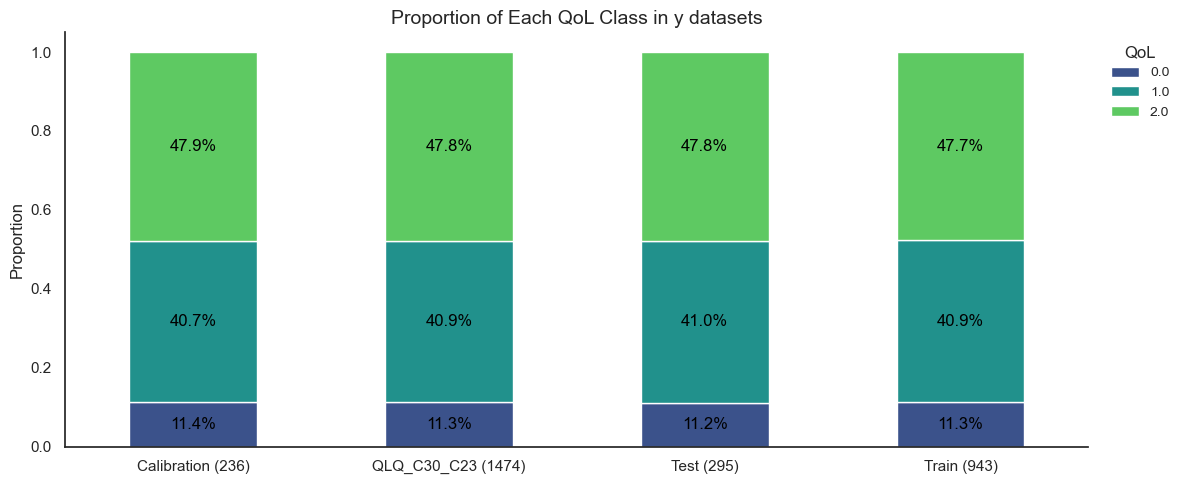

In [54]:
afn.viz_split_distributions([df['QoL'], y_train, y_test, y_cal], ['QLQ_C30_C23', 'Train', 'Test', 'Calibration'], 'QoL')

Podemos ver que la distribución de la variable objetivo tiene una variación inferior al 0.5% para cada clase en todos los conjuntos generados. Además, las 1474 observaciones del conjunto original se han separado en: 1031 para entrenamiento, 295 para pruebas y 148 para calibración.

In [55]:
# Guardamos los nombres de las clases de la variable objetivo para utilizarlas en las funciones auxiliares
labels = ['Baja', 'Media', 'Alta']

## 2. Entrenamiento y Clasificación

Como se ha mencionado, la clasificación se realizará en dos partes. En la primera, se utilizarán tres modelos supervisados: Decision Tree, Random Forest y XGBoost que corresponden a tres tipos distintos de algoritmos basados en árboles. De esta forma se podrá realizar un análisis preliminar de su comportamiento con el dataset. Un a vez se haya comprobado si la clasificación es viable se continuará con la segunda parte utilizando los algoritmos más costosos computacionalmente: CatBoost y LGBM. En el caso de que los resultados no fueran los esperados, se tomarán las acciones correctivas necesarias en la preparación de los datos para volver a realizar el modelado, tal como estipula el marco CRISP-DM.

La metodología a seguir en cada caso será:

***- Entrenamiento***

Entrenar el modelo con el conjunto de entrenamiento utilizando la técnica de validación cruzada k-fold con k=5, integrada en
el proceso de optimización de hiperparámetros mediante GridSearchCV. Esta técnica divide el conjunto de entrenamiento en
cinco particiones (folds): en cada iteración, cuatro se utilizan para entrenar y una para validar, repitiendo el proceso
rotativamente. Esta estrategia permite obtener una estimación más robusta del rendimiento general del modelo y reduce el
riesgo de sobre ajuste a una única partición de datos.

***- Métrica***

La métrica empleada para seleccionar la mejor combinación de hiperparámetros es el f1-score macro [1], que evalúa el
rendimiento equilibrado entre clases, sin favorecer a la clase mayoritaria. Esta métrica resulta especialmente adecuada para
el caso, en el que las clases media y alta presentan cierto grado de desbalance con respecto a la clase baja.
Mientras el f1-score ponderado podría verse influenciado por la clase alta, el f1-score macro calcula la
media aritmética simple del f1-score de cada clase, otorgando la misma importancia a cada una de ellas, independientemente del
número de muestras que contienen. Esto permite valorar el desempeño del modelo de forma justa en todas las categorías de
calidad de vida.

***- Clasificación***

Una vez obtenido el mejor modelo (*estimator*) generado por la combinación óptima de los hiperparámetros en la grilla, se obtendrá la predicción del conjunto de pruebas y se visualizarán los resultados comparativos con el entrenamiento para analizar el sobre ajuste y la calidad de la clasificación.

### 2.1 Decision Tree

El modelo utilizado es DecisionTreeClassifier de Scikit-learn [2], que permite configurar diversos hiperparámetros como el criterio de partición, la profundidad máxima del árbol y el número mínimo de muestras por nodo, entre otros. Un parámetro especialmente relevante en problemas con clases desbalanceadas es class_weight, que permite asignar pesos diferentes a cada clase, incrementando así la influencia de las clases minoritarias durante el entrenamiento y ayudando a mejorar su capacidad de detección. En el caso que nos ocupa, se asignará un peso mayor a la clase baja de QoL dentro de los parámetros utilizados en la búsqueda.

In [56]:
# Instanciamos el modelo 
dt_model =  DecisionTreeClassifier(random_state=73)
# Establecemos un diccionario con los valores de los parámetros que tomará el modelo en el entrenamiento
dt_parameters = {
    # Criterios para medir la ganancia de información (calidad de la división)
    'criterion': ['gini', 'entropy'],
    # Estrategias de división
    'splitter': ['best', 'random'],
    # Máxima profundidades del árbol (None permite la profundidad máxima posible)
    'max_depth': [10, 12, 14, None],
    # Mínimo de casos para dividir un nodo
    'min_samples_split': [3, 4, 5],
    # Mínimo de casos en las hojas
    'min_samples_leaf': [13, 14, 15],
    # Balanceo de clases
    'class_weight': [None, {0:3, 1:1, 2:1}],
}
# Creamos la grilla de búsqueda de parámetros con validación cruzada K-Folds con k=5 y paralelización de procesos
dt_grid = GridSearchCV(
    estimator=dt_model, 
    param_grid=dt_parameters, 
    verbose=1,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1
)
# Entrenamos los modelos en la búsqueda
dt_grid.fit(X_train, y_train)
# Visualización de los resultados
print('Media de F1 score:: %.3f' % dt_grid.best_score_)
print('Desviación estándar: ', dt_grid.cv_results_['std_test_score'][dt_grid.best_index_].round(3))
print('Parámetros que producen el clasificador óptimo: ')
print('Criterio: ', dt_grid.best_params_['criterion'])
print('Estrategia: ', dt_grid.best_params_['splitter'])
print('Profundidad máxima: ', dt_grid.best_params_['max_depth'])
print('Mínimo de muestras por división: ', dt_grid.best_params_['min_samples_split'])
print('Mínimo de muestras por hoja: ', dt_grid.best_params_['min_samples_leaf'])
print('Balanceo de clases: ', dt_grid.best_params_['class_weight'])
print('Cantidad de nodos: ', dt_grid.best_estimator_.tree_.node_count)
print('Cantidad de hojas: ', dt_grid.best_estimator_.tree_.n_leaves)

Fitting 5 folds for each of 288 candidates, totalling 1440 fits
Media de F1 score:: 0.610
Desviación estándar:  0.034
Parámetros que producen el clasificador óptimo: 
Criterio:  entropy
Estrategia:  best
Profundidad máxima:  10
Mínimo de muestras por división:  3
Mínimo de muestras por hoja:  15
Balanceo de clases:  None
Cantidad de nodos:  91
Cantidad de hojas:  46


El modelo óptimo encontrado presenta una estructura compuesta por 91 nodos y 46 hojas, distribuidos en 10 niveles de profundidad. El número mínimo de observaciones requerido para realizar una división es de 3, y cada hoja debe contener al menos 15 muestras.

El criterio que ha ofrecido mejor rendimiento es la división basada en la entropía, combinada con una estrategia best. Es interesante observar que el balanceo de clases (class_weight) no mejora el f1-score, ya que el modelo óptimo se obtiene con la opción None. Esto podría deberse a que la clase minoritaria no presenta fronteras claras respecto a las demás (es decir, no es fácilmente separable en el espacio de características), lo que limita el efecto del balanceo de pesos. También es posible que el propio árbol, con la configuración seleccionada, ya capture adecuadamente la estructura del problema sin necesidad de forzar una penalización adicional sobre las clases más frecuentes.

Finalmente, observamos que la media de F1-score de los modelos generados es un escaso 0,610, con una desviación estándar de 0,034. Esto significa que, en promedio, el modelo logra un equilibrio moderado entre precisión y recall a nivel de clase, pero sin alcanzar un rendimiento sobresaliente. La baja desviación indica que el comportamiento del modelo es relativamente estable a lo largo de los diferentes folds de validación cruzada, lo cual aporta confianza sobre la consistencia de los resultados, aunque estos no sean para nada óptimos. Esta situación sugiere que, si bien generaliza de forma razonable, podría no estar capturando adecuadamente la estructura subyacente del problema o enfrentarse a clases con fronteras difusas o solapamiento en el espacio de características.

Entrenamos el mejor modelo con el conjunto completo de los datos de entrenamiento (sin validación cruzada) y generamos las predicciones del conjunto de prueba. Para ello, nos valemos de la función auxiliar viz_classification_reports que se encargará de mostrar el reporte de las métricas y graficar la comparativa de entre ambos conjuntos

[codecarbon INFO @ 17:12:57] Energy consumed for RAM : 0.000250 kWh. RAM Power : 6.0 W
[codecarbon INFO @ 17:12:57] Delta energy consumed for CPU with constant : 0.000178 kWh, power : 42.5 W
[codecarbon INFO @ 17:12:57] Energy consumed for All CPU : 0.001772 kWh
[codecarbon INFO @ 17:12:57] 0.002022 kWh of electricity used since the beginning.
[codecarbon INFO @ 17:12:57] Energy consumed for RAM : 0.000125 kWh. RAM Power : 6.0 W
[codecarbon INFO @ 17:12:57] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 17:12:57] Energy consumed for All CPU : 0.000886 kWh
[codecarbon INFO @ 17:12:57] 0.001011 kWh of electricity used since the beginning.


Reporte sobre el conjunto de ENTRENAMIENTO:
              precision    recall  f1-score   support

         0.0       0.68      0.47      0.55       107
         1.0       0.70      0.73      0.71       386
         2.0       0.80      0.82      0.81       450

    accuracy                           0.75       943
   macro avg       0.72      0.67      0.69       943
weighted avg       0.74      0.75      0.74       943

Reporte sobre el conjunto de prueba:  PRUEBA
              precision    recall  f1-score   support

         0.0       0.52      0.36      0.43        33
         1.0       0.62      0.64      0.63       121
         2.0       0.73      0.77      0.75       141

    accuracy                           0.67       295
   macro avg       0.62      0.59      0.60       295
weighted avg       0.66      0.67      0.66       295



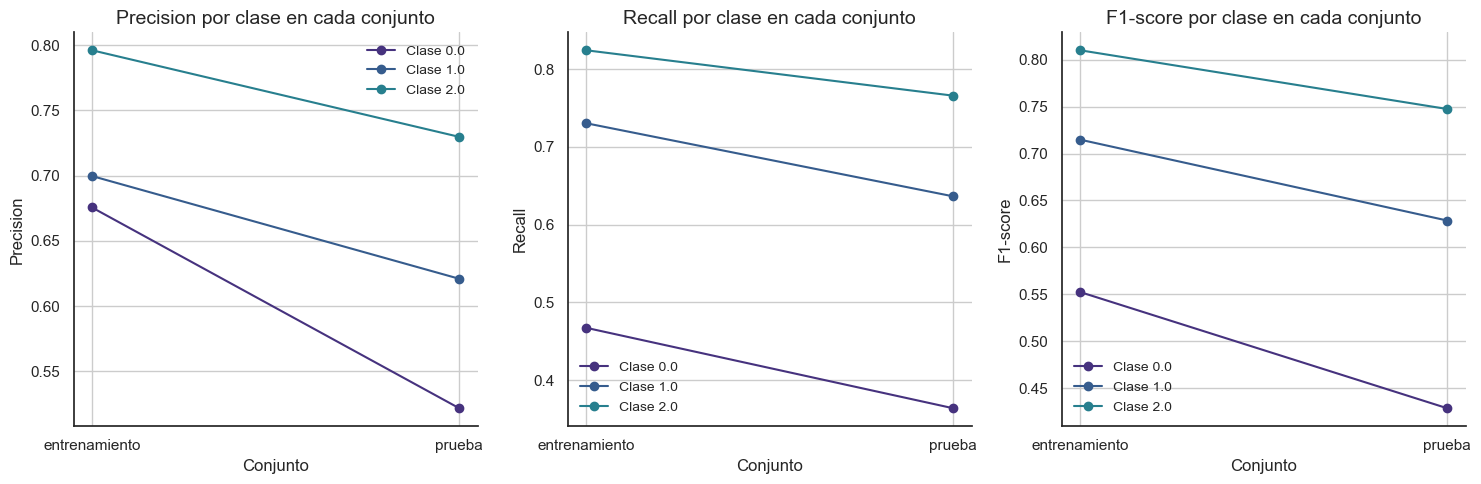

In [57]:
# Obtenemos el mejor modelo y realizamos las predicciones de prueba
dt_model = dt_grid.best_estimator_
y_pred_train_dt, y_pred_test_dt, report_dt = afn.viz_classification_reports(dt_model, X_train, y_train, X_test, y_test, 'prueba')


El modelo generado mediante GridSearchCV y validación cruzada alcanza un f1-score macro de 0.69 en entrenamiento, que desciende a 0.60 en el conjunto de prueba. Esta diferencia indica una pérdida de rendimiento entre ambos conjuntos, aunque el modelo mantiene una capacidad general de clasificación aceptable. Es decir, que no se aprecia un sobreajuste marcado y no es necesario reducir la complejidad mediante técnicas de poda. No obstante, al analizar el desempeño por clase, se observa una clara disparidad, especialmente en la clase 0 (QoL baja).

En el conjunto de prueba, esta clase presenta un recall de 0.27, lo que implica que el modelo apenas identifica casi uno de cada cuatro casos reales. La precisión es de 0.50, indicando que la mitad de las predicciones realizadas para esta clase no son correctas.

En cambio, las clases 1 (media) y 2 (alta) muestran un comportamiento más equilibrado. La clase 1 mantiene un f1-score de 0.60 en prueba, mientras que la clase 2 alcanza un aceptable 0.75, con un recall del 79%, siendo esta última la clase con mejor desempeño.

En conjunto, los resultados muestran que el modelo tiende a confundir las clases limítrofes —principalmente baja con media—, lo que puede significar la posible necesidad de replantear el problema de clasificación.

Vamos a observar mas detalladamente el comportamiento mediante la matriz de confusión en el conjunto de prueba:

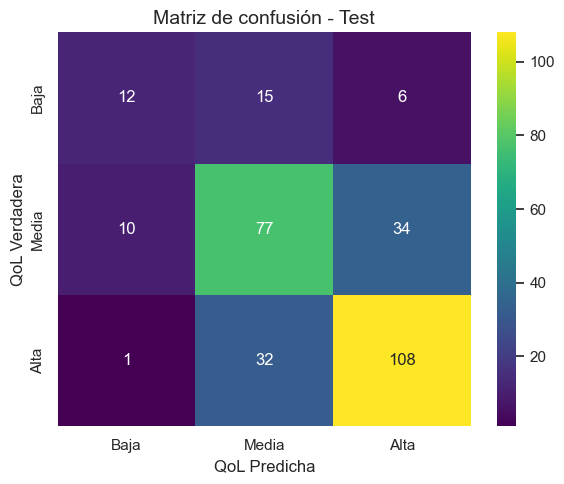

In [58]:
afn.viz_confusion_matrix_test(labels, y_test, y_pred_test_dt)

La matriz de confusión del conjunto de prueba confirma visualmente las conclusiones obtenidas mediante los informes de métricas. La clase baja
muestra una fuerte dispersión en sus predicciones: de los 33 casos reales, solo 12 fueron correctamente clasificados, mientras que 15 fueron confundidos con la clase media y 6 con la clase alta, esto corresponde al recall de 0.36. Es decir, la clase baja se clasifica más como clase media. Además de las 23 clasificaciones de esta clase que realiza el modelo casi la mitad son erróneas, mayormente confundidas con clase media, esto corresponde al 50% de precisión.

En cambio, la clase media tiene 77 aciertos sobre 121 instancias, aunque también presenta un número no despreciable de errores: 10 con la clase baja y 34 casos fueron clasificados como clase alta, lo que sugiere que existe confusión entre estas dos categorías. Finalmente, la clase alta presenta el mejor rendimiento, con 108 aciertos sobre 141 instancias, aunque también sufre confusiones con la clase media (32 casos).

En conjunto, esta matriz pone de manifiesto que la mayoría de los errores de clasificación se producen entre clases adyacentes, especialmente entre la baja y la media, aunque no es despreciable entre la media y la alta. Esto refuerza la hipótesis del solapamiento entre clases contiguas en términos de sus características. En particular, el modelo no es capaz de identificar la clase baja de forma efectiva, lo que podría deberse tanto a una representación insuficiente de esta clase en el conjunto de entrenamiento como a una falta de separación clara en el espacio de características, sobre todo, con respecto a la clase media.

### 2.2 Random Forest

Random Forest es un algoritmo de aprendizaje supervisado basado en el principio de ensemble learning, que construye múltiples árboles de decisión durante el entrenamiento y produce la predicción final mediante votación mayoritaria (para clasificación) o promedio (para regresión). Cada árbol es entrenado con una muestra aleatoria (con reemplazo) del conjunto de entrenamiento —una técnica conocida como bagging—, y en cada nodo se selecciona aleatoriamente un subconjunto de características para decidir la mejor partición. Esta aleatoriedad ayuda a reducir el sobreajuste que suele afectar a los árboles individuales y mejora la capacidad de generalización del modelo.

Random Forest es especialmente robusto frente a datos ruidosos, escalas heterogéneas y correlaciones entre variables. Además, permite estimar la importancia de las variables y proporciona medidas internas de error sin necesidad de un conjunto de validación independiente.

En Scikit-learn, el modelo se implementa mediante la clase RandomForestClassifier [3], que permite configurar el número de árboles, el criterio de partición, la profundidad máxima, el número mínimo de muestras por división o por hoja, y si se desea aplicar balanceo de clases mediante class_weight, entre otros hiperparámetros, todos muy similares a DecisionTreeClassifier.

Continuando con la misma estrategia, entrenamos la grilla de búsqueda con los parámetros y el modelo:

In [59]:
# Instanciamos el modelo
rf_model = RandomForestClassifier(
    random_state = 73,
    n_jobs=-1
)
# Creamos la grilla con los parámetros al igual que en el caso anterior pero añadiendo el número de árboles cada generar los bosques.
rf_parameters = {
    'criterion': ['entropy'],
    # Número de árboles en cada modelo
    'n_estimators': [100],
    'max_depth': [12],
    'min_samples_split': [4],
    'min_samples_leaf': [4],
    'class_weight': [None, {0:3, 1:1, 2:1}],
    # Factor alpha para la poda
    'ccp_alpha': [0.009]
}
# Instanciamos la grilla
rf_grid = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_parameters,
    scoring='f1_macro',
    verbose=True,
    cv=5,
    n_jobs=-1
)
# Realizamos el entrenamiento para generar la búsqueda
rf_grid.fit(X_train, y_train)
# Visualizamos los resultados
print('Media de F1 score: %.3f' % rf_grid.best_score_)
print('Desviación estándar: ', rf_grid.cv_results_['std_test_score'][rf_grid.best_index_].round(3))
print('Parámetros que producen el clasificador óptimo: ')
print('Criterio: ', rf_grid.best_params_['criterion'])
print('Profundidad máxima: ', rf_grid.best_params_['max_depth'])
print('Mínimo de muestras por división: ', rf_grid.best_params_['min_samples_split'])
print('Mínimo de muestras por hoja: ', rf_grid.best_params_['min_samples_leaf'])
print('Balanceo de clases: ', rf_grid.best_params_['class_weight'])
print('Alpha: ', rf_grid.best_params_['ccp_alpha'])
print('Cantidad de árboles: ', rf_grid.best_params_['n_estimators'])
print('Cantidad de nodos del primer árbol: ', rf_grid.best_estimator_.estimators_[0].tree_.node_count)
print('Cantidad de hojas del primer árbol: ', rf_grid.best_estimator_.estimators_[0].tree_.n_leaves)    

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Media de F1 score: 0.663
Desviación estándar:  0.033
Parámetros que producen el clasificador óptimo: 
Criterio:  entropy
Profundidad máxima:  12
Mínimo de muestras por división:  4
Mínimo de muestras por hoja:  4
Balanceo de clases:  {0: 3, 1: 1, 2: 1}
Alpha:  0.009
Cantidad de árboles:  100
Cantidad de nodos del primer árbol:  59
Cantidad de hojas del primer árbol:  30


El modelo óptimo encontrado presenta una estructura base compuesta por 100 árboles, de los cuales el primero tiene 63 nodos y 32 hojas, con una profundidad máxima de 12 niveles. Cada árbol requiere un mínimo de 4 observaciones para realizar una división y al menos 4 observaciones por hoja, lo que restringe la creación de ramas pequeñas y promueve una mayor generalización. Se ha aplicado además un valor de ccp_alpha de 0.008, que introduce un proceso de poda para reducir la complejidad del modelo y mitigar el sobreajuste.

El criterio que ha ofrecido mejor rendimiento en la grilla es la entropía, lo que indica que la ganancia de información ha sido más efectiva que el índice de Gini o la pérdida logarítmica en la construcción de los árboles. En cuanto al tratamiento del desbalance, se observa que la mejor configuración es la que incorpora un esquema de pesos ajustados a favor de la clase minoritaria.

Finalmente, se obtiene una media de F1-score de 0.665, con una desviación estándar de 0.03. Esto representa una mejora sustancial, aunque insuficiente, respecto al árbol individual. La baja desviación muestra que el modelo mantiene un comportamiento coherente a lo largo de las diferentes particiones de validación cruzada. En conjunto, el modelo parece capturar mejor la estructura del problema que el árbol simple, aunque persisten desafíos en la separación clara entre clases.

Reporte sobre el conjunto de ENTRENAMIENTO:
              precision    recall  f1-score   support

         0.0       0.71      0.74      0.72       107
         1.0       0.77      0.71      0.74       386
         2.0       0.79      0.84      0.82       450

    accuracy                           0.78       943
   macro avg       0.76      0.76      0.76       943
weighted avg       0.78      0.78      0.78       943

Reporte sobre el conjunto de prueba:  PRUEBA
              precision    recall  f1-score   support

         0.0       0.53      0.52      0.52        33
         1.0       0.67      0.60      0.63       121
         2.0       0.73      0.81      0.77       141

    accuracy                           0.69       295
   macro avg       0.64      0.64      0.64       295
weighted avg       0.68      0.69      0.68       295



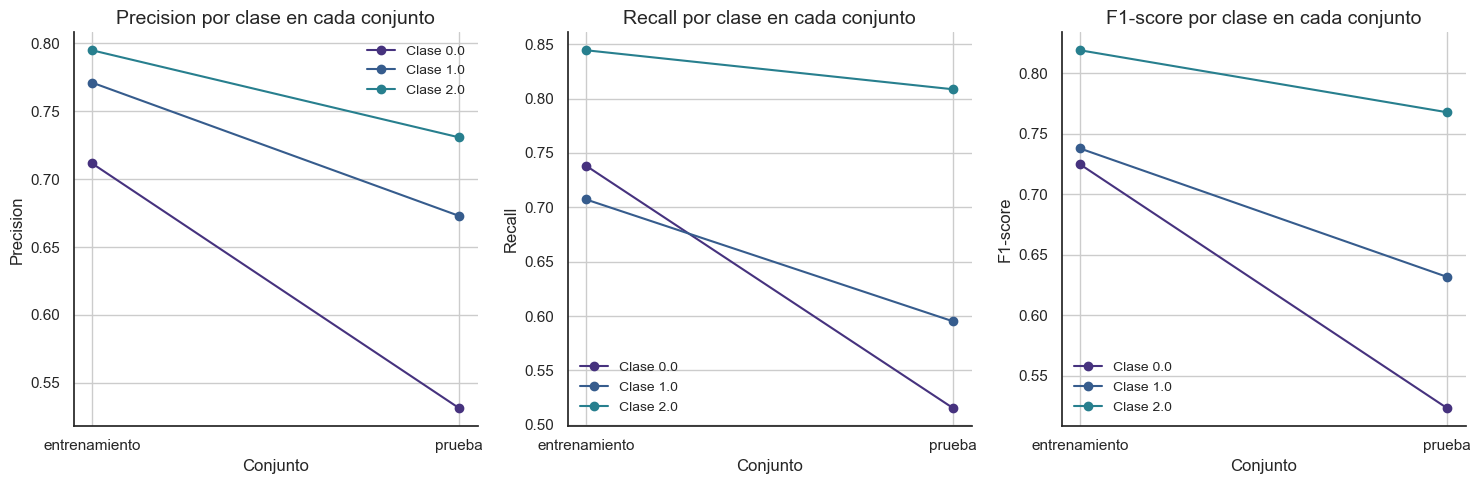

In [60]:
rf_model = rf_grid.best_estimator_
y_pred_train_rf, y_pred_test_rf, report_rf = afn.viz_classification_reports(rf_model, X_train, y_train, X_test, y_test, 'prueba')

El modelo con los mejores hiperparámetros seleccionados por GridSearchCV muestra una mejora sustancial en el rendimiento general respecto al árbol de decisión único. En el conjunto de entrenamiento alcanza un f1-score macro de 0.78, mientras que en el conjunto de prueba desciende a 0.64, una caída moderada que no indica sobreajuste severo y confirma una generalización «razonable» del modelo. La precisión global se mantiene en 0.69, y las métricas por clase reflejan una distribución más equilibrada.

El comportamiento por clase evidencia un avance relativamente importante. En particular, la clase 0 (QoL baja), que en el modelo anterior era la más penalizada, presenta ahora un f1-score de 0.48, con precisión y recall casi iguales (0.47 y 0.48 respectivamente), lo que denota que el modelo ha logrado capturar mejor los patrones de esta clase minoritaria. Sin embargo, la abrupta caída en todas las métricas de ≈0.30 indica un mayor sobreajuste para esta clase.

Por su parte, las clases media (1) y alta (2) mantienen buenos niveles de desempeño. La clase 2 continúa siendo la mejor clasificada, ambas clases poseen desviaciones moderadas entre entrenamiento y prueba, lo que sugiere estabilidad.

Profundizamos el comportamiento del modelo mediante la visualización de la matriz de confusión:

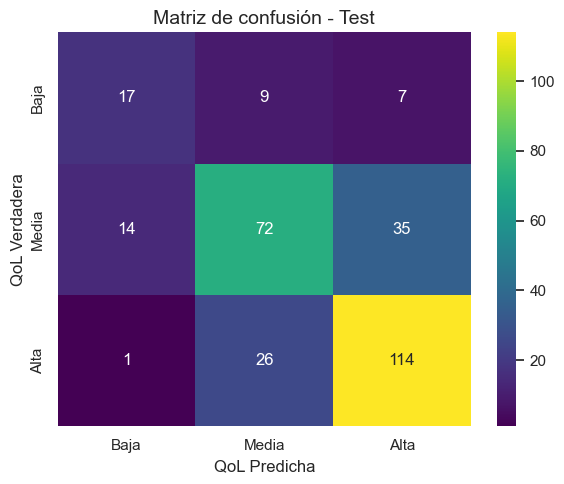

In [61]:
afn.viz_confusion_matrix_test(labels, y_test, y_pred_test_rf)

La matriz de confusión revela una mejora en la identificación de la clase baja respecto al árbol de decisión. De los 33 casos reales pertenecientes a esta clase, 17 fueron correctamente clasificados, lo que representa un recall del 51%. Aun así, se siguen observando 9 errores hacia la clase media y 7 hacia la clase alta, indicando que persiste la confusión con las clases contiguas.

En la clase media, el modelo acierta en 72 de los 121 casos, pero confunde 15 con la clase baja y 34 con la clase alta. Aunque el modelo logra capturar parte del patrón de esta clase, su frontera sigue siendo difusa, especialmente respecto a la clase alta.

En cuanto a la clase alta, el modelo muestra un rendimiento mejor, con 114 aciertos sobre 141 casos, con 27 errores distribuidos entre las clases baja (1) y media (26). Esto indica que el modelo tiene mayor capacidad para identificar correctamente esta clase, probablemente porque sus patrones son más nítidos y diferenciables en el espacio de características, además de ser la más numerosa.

En conjunto, la matriz de confusión refleja que el modelo tiende a confundir principalmente entre clases vecinas, lo que respalda el resultado del árbol de decisión. Si bien las métricas globales han mejorado, la clase baja sigue siendo la más conflictiva, aunque el desempeño del modelo ha progresado en su detección en comparación con el intento previo, continúa siendo insuficiente.

### 2.3 XGBoost

Extreme Gradient Boosting es un algoritmo de aprendizaje supervisado basado en árboles de decisión que pertenece a la familia de los métodos de boosting por gradiente. Su objetivo principal es mejorar la precisión de modelos más simples, como los árboles individuales, mediante la combinación secuencial de múltiples árboles que corrigen los errores cometidos por los anteriores.

A diferencia de Random Forest, que construye árboles en paralelo de forma independiente (bagging), XGBoost los construye de forma secuencial, cada uno enfocado en los errores residuales del anterior. Este proceso permite reducir el sesgo del modelo y obtener predicciones más ajustadas. Para ello, se basa en una técnica de optimización que utiliza el gradiente del error como guía para actualizar los modelos sucesivos, de ahí el nombre «Gradient Boosting».

Las características más importantes del algoritmo son:

- Poda de árboles durante el entrenamiento en lugar de después
- Regularización L1 y L2 que le permite reducir el sobreajuste
- Paralelización interna y utilización optimizada de la memoria
- Manejo automático de valores faltantes

El algoritmo utilizado es el XGBoostClassifier [4]. Además de los parámetros que poseen la mayoría de los algoritmos basados en árboles, XGBoost permite establecer otras características avanzadas:

***La función de pérdida***: mide cuánto se equivoca el modelo al hacer una predicción. El algoritmo utiliza esta función en cada iteración para calcular el gradiente y mejorar el modelo ajustando los errores residuales. Según el tipo de problema, se utiliza una función de pérdida distinta, en el caso de la clasificación multiclase mlogloss es la indicada. Además, incluye un término de regularización para penalizar modelos complejos, lo que reduce el sobreajuste. Esta regularización se aplica sobre la estructura del árbol (profundidad, número de hojas, etc.).

***El submuestreo aleatorio de columnas***: consiste en seleccionar aleatoriamente un subconjunto de variables en cada árbol, nivel o nodo del modelo. Esto introduce diversidad en la construcción de los árboles, reduce la correlación entre ellos y mejora la capacidad de generalización. XGBoost permite configurarlo con varios parámetros: colsample_bytree (por árbol), colsample_bylevel (por nivel) y colsample_bynode (por nodo). Esta técnica es especialmente útil en datasets con muchas variables, ya que disminuye el riesgo de sobreajuste y reduce el tiempo de entrenamiento. Es decir, añade un componente estocástico haciendo que los árboles se especialicen de forma diferente, como en Random Forest.

Continuamos con la misma estrategia entrenando la grilla de búsqueda:




In [62]:
# Instanciamos el modelo
xg_model = XGBClassifier(
    objective='multi:mlogloss',
    eval_metric='mlogloss',
    random_state=73,
)
# Creamos el diccionario e hiperparámetros
xg_parameters = {
    'max_depth': [6],
    'min_child_weight': [4],
    'n_estimators': [80],
    # Fracción de muestras utilizadas. Forzamos el uso del 50 de las variables para limitar el sobreajuste.
    'subsample': [0.5],
    # Tasa de aprendizaje, controla el tamaño de los pasos en cada iteración.
    'learning_rate': [0.06],
    # Regularización L1, penaliza la suma de valores absolutos de las hojas.
    'reg_alpha': [0.12],
    # Regularización L2 penaliza la suma de los cuadrados de las hojas.
    'reg_lambda': [0.11]
}
# Instanciamos la grilla de búsqueda
xg_grid = GridSearchCV(
    estimator=xg_model,
    param_grid=xg_parameters,
    scoring='f1_macro',
    cv=5,
    verbose=True,
    n_jobs=-1
)
# Realizamos el entrenamiento
xg_grid.fit(X_train, y_train)
# Visualizamos los resultados
print('Media de F1 score: %.3f' % xg_grid.best_score_)
print('Desviación estándar: ', xg_grid.cv_results_['std_test_score'][xg_grid.best_index_].round(3))
print('Parámetros que producen el clasificador óptimo: ')
print('Tasa de aprendizaje: ', xg_grid.best_params_['learning_rate'])
print('L1: ', xg_grid.best_params_['reg_alpha'])
print('L2: ', xg_grid.best_params_['reg_lambda'])
print('Profundidad máxima: ', xg_grid.best_params_['max_depth'])
print('Mínimo peso de división: ', xg_grid.best_params_['min_child_weight'])
print('Número de árboles: ', xg_grid.best_params_['n_estimators'])
print('Subsample: ', xg_grid.best_params_['subsample'])

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Media de F1 score: 0.652
Desviación estándar:  0.038
Parámetros que producen el clasificador óptimo: 
Tasa de aprendizaje:  0.06
L1:  0.12
L2:  0.11
Profundidad máxima:  6
Mínimo peso de división:  4
Número de árboles:  80
Subsample:  0.5


El modelo óptimo encontrado por GridSearchCV está formado por 80 árboles con una profundidad máxima de 6, lo que sugiere una estructura controlada para evitar sobreajuste. El min_child_weight de 4 impone un umbral mínimo de evidencia para realizar divisiones, y el subsample del 50% reduce la varianza al entrenar cada árbol con solo la mitad de los datos disponibles. 

Se ha ajustado una tasa de aprendizaje de 0.06, que modula el impacto de cada árbol en el resultado final, junto con una regularización activa mediante L1 y L2, que penalizan árboles complejos y mejoran la capacidad de generalización. Esta estrategia reemplaza el mecanismo de poda empleado en otros algoritmos basados en árboles como Random Forest.

El modelo alcanza un pobre f1-score macro medio de 0.652 con una desviación estándar de 0.038, lo que refleja un rendimiento estable a lo largo de las particiones de validación cruzada.

Vamos a analizar en profundidad el modelo óptimo encontrado con la búsqueda por grilla:

Reporte sobre el conjunto de ENTRENAMIENTO:
              precision    recall  f1-score   support

         0.0       0.86      0.63      0.72       107
         1.0       0.82      0.83      0.83       386
         2.0       0.85      0.90      0.88       450

    accuracy                           0.84       943
   macro avg       0.85      0.79      0.81       943
weighted avg       0.84      0.84      0.84       943

Reporte sobre el conjunto de prueba:  PRUEBA
              precision    recall  f1-score   support

         0.0       0.50      0.33      0.40        33
         1.0       0.66      0.64      0.65       121
         2.0       0.74      0.81      0.77       141

    accuracy                           0.69       295
   macro avg       0.63      0.60      0.61       295
weighted avg       0.68      0.69      0.68       295



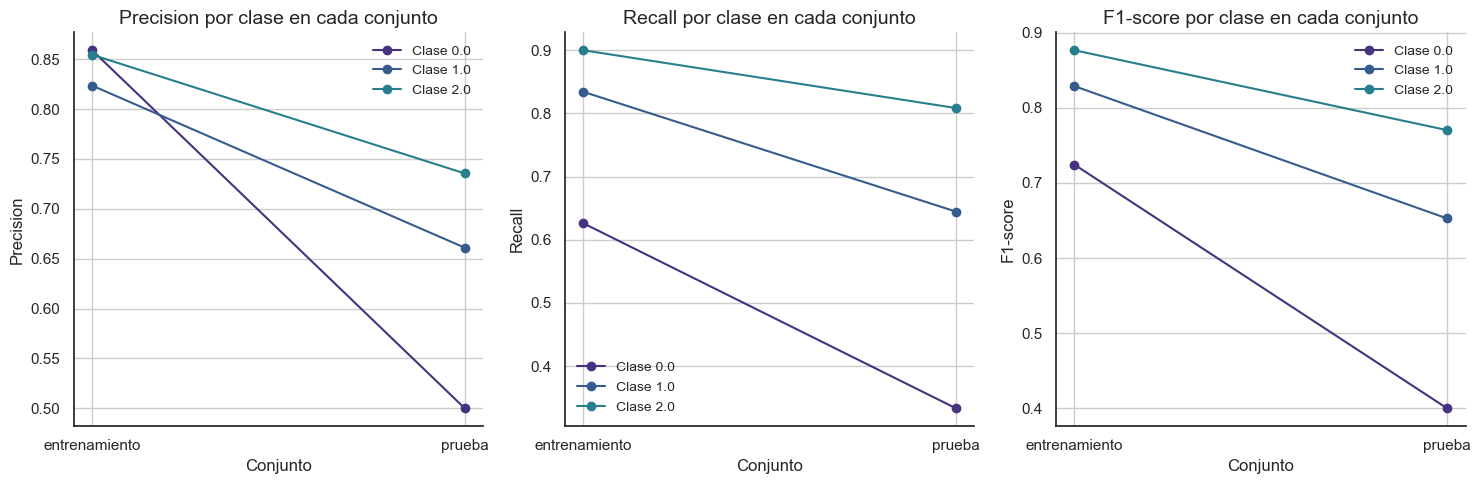

In [63]:
xg_model = xg_grid.best_estimator_
xg_model.fit(X_train, y_train)
y_pred_train_xg, y_pred_test_xg, report_xg = afn.viz_classification_reports(xg_model, X_train, y_train, X_test, y_test, 'prueba')


Aunque el modelo de XGBoost mejora significativamente las métricas generales y muestra una mayor capacidad de modelado, no logra mantener un mejor equilibrio entre precisión y recall para todas las clases. En particular, la clase 0 (QoL baja) experimenta una caída pronunciada en todas las métricas, indicando que sigue siendo la clase peor representada y más difícil de detectar. La clase 2 (alta) sí muestra mejoras consistentes y es la más robusta, pero el modelo no logra un equilibrio global superior entre clases, sino que continúa penalizando severamente la clase minoritaria y presenta un sobreajuste más pronunciado que los modelos anteriores.

Vamos a profundizar observando la matriz de confusión como en los casos anteriores:

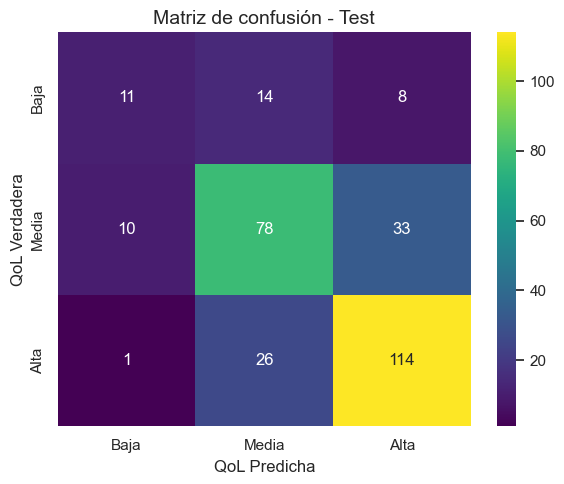

In [64]:
afn.viz_confusion_matrix_test(labels, y_test, y_pred_test_xg)

La matriz de confusión muestra que el modelo XGBoost logra clasificar correctamente 11 de los 33 casos reales de la clase baja, mientras que confunde 14 con la clase media y 8 con la clase alta. Esto se traduce en un recall de apenas 0.42, indicando que más de la mitad de los casos con baja calidad de vida no son correctamente detectados. A pesar de la alta precisión obtenida durante el entrenamiento, esta caída notable en recall evidencia un problema de generalización para la clase minoritaria.

En la clase media, el modelo acierta en 78 de 121 casos, pero también incurre en 10 errores hacia la clase baja y 33 hacia la clase alta, lo que indica una confusión bidireccional, aunque más acentuada con la clase superior. Aun así, esta clase se mantiene con un rendimiento razonablemente estable y mejora la clasificación con respecto a los modelos anteriores.

Por su parte, la clase alta obtiene 114 aciertos de 141, siendo confundida 26 veces con la media y solo 1 con la baja. Esto sugiere que el modelo detecta mejor los patrones característicos de esta categoría. En general, XGBoost logra buenos resultados en las clases más representadas, pero su desempeño para la clase baja sigue siendo insatisfactorio, lo que pone de manifiesto las limitaciones del modelo frente al desbalance y la complejidad del espacio de decisión en los casos extremos.

## 3. Análisis Parcial

Como hemos podido observar, los tres modelos obtienen resultados similares, aunque con diferencias significativas en términos de equilibrio entre clases y estabilidad. El modelo Random Forest ha mostrado el mejor rendimiento global, con una media de f1-score de 0.64 en el conjunto de prueba, un comportamiento más robusto frente al desbalance y una caída menos pronunciada en las métricas por clase respecto al entrenamiento. Consigue identificar correctamente 17 de los 33 casos de la clase baja, lo que representa un recall del 0.52, superior al obtenido por los otros modelos.

En el caso del árbol de decisión, el rendimiento es claramente más limitado. Presenta una estructura simple y poco profunda, lo que restringe su capacidad de capturar relaciones complejas en los datos. El modelo muestra la mayor caída de f1-score en la clase baja (de 0.42 a 0.22), evidenciando su baja capacidad de generalización, especialmente frente al solapamiento entre clases.

El modelo XGBoost, por su parte, ha mostrado un rendimiento más estable en las clases media y alta, con valores de f1-score elevados y consistentes. Sin embargo, en la clase baja solo logra clasificar correctamente 14 de 33 observaciones, con una caída importante en recall (hasta 0.42) respecto al entrenamiento. A pesar de su complejidad y técnicas avanzadas como la regularización y el submuestreo, el modelo sigue sin resolver de forma efectiva la separación de los casos minoritarios.

En conjunto, los tres modelos enfrentan una limitación compartida: la dificultad para separar correctamente la clase baja, lo que sugiere la necesidad de explorar nuevos planteamientos del problema con los datos disponibles.

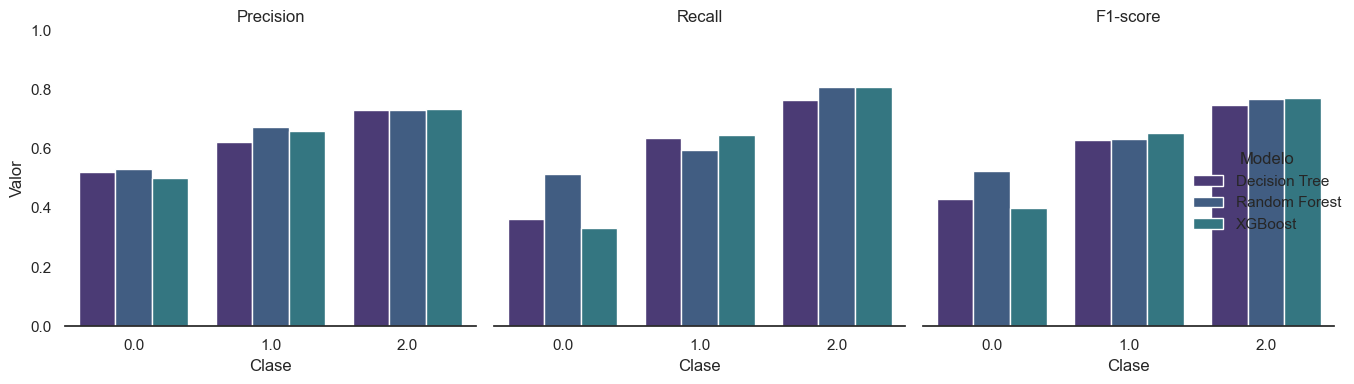

In [65]:
# Visualizamos el comportamiento de los 3 modelos comparativamente utilizando la función auxiliar viz_model_comparison que recibe un diccionario con los reportes de cada modelo y muestra los resultados de cada uno para precision, recall y f1 score
afn.viz_model_comparison({
    'Decision Tree': report_dt,
    'Random Forest': report_rf,
    'XGBoost': report_xg
})

El gráfico muestra la comparación del rendimiento por clase (0: baja, 1: media, 2: alta) de los tres modelos evaluados —Decision Tree, Random Forest y XGBoost— usando tres métricas: precisión, recall y f1-score.

En la clase baja (0.0), Random Forest alcanza el mejor recall, mientras que XGBoost destaca en precisión y f1-score. La clase media (1.0) es relativamente bien clasificada por los tres modelos, aunque XGBoost presenta el f1-score más alto. Para la clase alta (2.0), todos los modelos tienen un rendimiento elevado y similar, aunque Random Forest y XGBoost ligeramente por encima.

En conjunto, XGBoost muestra el comportamiento más equilibrado entre métricas y clases, aunque la clase baja sigue siendo la más difícil de clasificar correctamente para todos los modelos.

## 4. Conclusiones 

Los resultados obtenidos hasta el momento evidencian que abordar la predicción del índice de calidad de vida como un problema de clasificación multiclase no resulta eficaz, dada la complejidad y el solapamiento de los patrones presentes en los datos. Por tanto, se hace necesario replantear el enfoque para poder avanzar hacia el objetivo final.

Desde una perspectiva más pragmática, cabe preguntarse cuál es la frontera significativa que debemos establecer entre una calidad de vida aceptable y una que puede ser objeto de mejora. Si el propósito es identificar a las personas cuyo estado debe ser intervenido, tiene sentido unificar las clases media y baja bajo una categoría común —mejorable—, reservando la clase aceptable para aquellos casos con una calidad de vida claramente positiva. Este cambio transforma el problema en una clasificación binaria más alineada con la finalidad práctica del sistema.

De este modo, se propone redefinir el etiquetado de los datos para representar únicamente dos categorías: aceptable y mejorable. Este nuevo enfoque permitirá no solo simplificar la tarea de clasificación, sino también incorporar técnicas específicas como el ajuste de umbral de decisión, orientadas a optimizar la detección de los casos más relevantes: aquellos que requieren mejora.

En resumen, el tratamiento multiclase no ha ofrecido una capacidad predictiva suficientemente robusta para alcanzar los objetivos propuestos. A partir de ahora, el modelado se centrará en una clasificación binaria, más adecuada para detectar situaciones donde la calidad de vida de los pacientes puede y debe ser mejorada.

## 5. Bibliografía

[1] Chicco, Davide. (2019, 3 de septiembre). Micro, macro, weighted averages of F1 score: clearly explained [artículo en línea]. Towards Data Science. [Fecha de consulta: 12 de abril de 2025]. https://towardsdatascience.com/micro-macro-weighted-averages-of-f1-score-clearly-explained-b603420b292f

[2] Scikit-learn Developers. (s.f.). sklearn.tree.DecisionTreeClassifier [documentación en línea]. Scikit-learn. [Fecha de consulta: 12 de abril de 2025]. https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

[3] Scikit-learn Developers. (s.f.). sklearn.ensemble.RandomForestClassifier [documentación en línea]. Scikit-learn. [Fecha de consulta: 12 de abril de 2025]. https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html#sklearn.ensemble.RandomForestClassifier

[4] XGBoost Developers. (s.f.). XGBoost Documentation – Release 3.0.0 [documentación en línea]. [Fecha de consulta: 16 de abril de 2025]. https://xgboost.readthedocs.io/en/release_3.0.0/index.html

In [66]:
emissions: float = tracker.stop()  # devuelve kg CO₂e
print(f"💡 Emisiones estimadas: {emissions:.3f} kg CO₂e")

[codecarbon INFO @ 17:13:01] Energy consumed for RAM : 0.000011 kWh. RAM Power : 6.0 W
[codecarbon INFO @ 17:13:01] Delta energy consumed for CPU with constant : 0.000076 kWh, power : 42.5 W
[codecarbon INFO @ 17:13:01] Energy consumed for All CPU : 0.000076 kWh
[codecarbon INFO @ 17:13:01] 0.000087 kWh of electricity used since the beginning.


💡 Emisiones estimadas: 0.000 kg CO₂e
